In [ ]:
# ===============================
# 1. ORTAM & DRIVE AYARLARI
# ===============================

# Temel kütüphaneler
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Colab Drive
from google.colab import drive

# -------------------------------
# Google Drive bağla
# -------------------------------
drive.mount('/content/drive')

# -------------------------------
# Proje yolları
# -------------------------------
PROJECT_ROOT = "/content/drive/My Drive/BoneAgeProject"
DATASET_DIR  = os.path.join(PROJECT_ROOT, "DATASET")
MODEL_DIR    = os.path.join(PROJECT_ROOT, "models")

# -------------------------------
# Dataset alt klasörleri
# -------------------------------
Articular_Surface_Train = os.path.join(DATASET_DIR, "Articular_Surface_Train")
Articular_Surface_Val   = os.path.join(DATASET_DIR, "Articular_Surface_Val")

Epiphysis_Train = os.path.join(DATASET_DIR, "Epiphysis_Train")
Epiphysis_Val   = os.path.join(DATASET_DIR, "Epiphysis_Val")

train_csv = os.path.join(DATASET_DIR, "train.csv")
val_csv   = os.path.join(DATASET_DIR, "val.csv")

# -------------------------------
# Global sabitler
# -------------------------------
IMG_SIZE   = 320
BATCH_SIZE = 8
MAX_AGE    = 228

# -------------------------------
# Ortam bilgisi (kontrol amaçlı)
# -------------------------------
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Proje dizini:", PROJECT_ROOT)
print("Dataset dizini:", DATASET_DIR)
print("Model kayıt dizini:", MODEL_DIR)


Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Proje dizini: /content/drive/My Drive/BoneAgeProject
Dataset dizini: /content/drive/My Drive/BoneAgeProject/DATASET
Model kayıt dizini: /content/drive/My Drive/BoneAgeProject/models


In [ ]:
# ===============================
# 2. VERİ YÜKLEME & tf.data
# ===============================
# -------------------------------
# CSV'den path ve etiketleri yükle
# -------------------------------

def load_csv(csv_path, art_dir, epi_dir):
    df = pd.read_csv(csv_path)

    art_paths, epi_paths, males, y = [], [], [], []

    for row in df.itertuples():
        pid = str(row.id)

        art = os.path.join(art_dir, pid + ".png")
        epi = os.path.join(epi_dir, pid + ".png")

        if not (os.path.exists(art) and os.path.exists(epi)):
            continue

        art_paths.append(art)
        epi_paths.append(epi)
        males.append(1.0 if row.male else 0.0)
        y.append(np.float32(row.boneage) / MAX_AGE)

    return art_paths, epi_paths, males, y

# -------------------------------
# tf.data içinde tek örnek okuma ve ön-işleme
# -------------------------------
def parse_sample(art_path, epi_path, male, y):
    art = tf.io.read_file(art_path)
    art = tf.image.decode_png(art, channels=1)
    art = tf.image.resize(art, (IMG_SIZE, IMG_SIZE))

    epi = tf.io.read_file(epi_path)
    epi = tf.image.decode_png(epi, channels=1)
    epi = tf.image.resize(epi, (IMG_SIZE, IMG_SIZE))

    const = tf.zeros_like(art)

    img = tf.concat([art, epi, const], axis=-1)
    img = preprocess_input(img)

    return {
        "img_input": img,
        "male_input": tf.expand_dims(male, -1)
    }, y


# -------------------------------
# Train / Validation path listelerini oluştur
# -------------------------------
art_t, epi_t, male_t, y_t = load_csv(
    train_csv, Articular_Surface_Train, Epiphysis_Train
)

art_v, epi_v, male_v, y_v = load_csv(
    val_csv, Articular_Surface_Val, Epiphysis_Val
)

# -------------------------------
# tf.data Dataset nesnelerini oluştur
# -------------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    (art_t, epi_t, tf.cast(male_t, tf.float32), tf.cast(y_t, tf.float32))
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (art_v, epi_v, tf.cast(male_v, tf.float32), tf.cast(y_v, tf.float32))
)


# -------------------------------
# tf.data pipeline:
# shuffle → parse → batch → prefetch
# -------------------------------
train_ds = (
    train_ds
    .shuffle(1000)
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .shuffle(100)
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("Veriler yüklendi.")

print("tf.data pipeline hazır.")


Veriler yüklendi.
tf.data pipeline hazır.


In [ ]:
# ===============================
# 3. MODEL TANIMI
# ===============================

# --- EfficientNet Backbone ---
def build_model():
    img_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="img_input"
    )
    male_input = layers.Input(shape=(1,), name="male_input")

    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )

    for layer in base.layers:
        layer.trainable = False

    for layer in base.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    feat = base(img_input)

    x = layers.Concatenate()([feat, male_input])

    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(
        inputs=[img_input, male_input],
        outputs=out
    )



# --- Ana Model ---


# Modeli oluştur ve özetle
model = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ img_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ male_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1281)      │          0 │ efficientnetb0[0… │
│ (Concatenate)       │                   │            │ male_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    656,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,771,748 (18.20 MB)

 Trainable params: 1,843,761 (7.03 MB)

 Non-trainable params: 2,927,987 (11.17 MB)

In [ ]:
# ===============================
# 4. COMPILE & EĞİTİM
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=4e-4,
        weight_decay=1e-5
    ),
    loss="mae",
)


# --- Callback'ler ---

#--------İyilişmezse durdur
cb_early = EarlyStopping(
    monitor="val_loss",
    patience=20,
    mode="min",
    restore_best_weights=True,
    verbose=1,
)

#-----Öğrenme hızını düşür-----
cb_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.6,
    patience=4,
    mode="min",
    min_lr=1e-6,
    verbose=1,
)

# --- MODELİ EĞİT ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[cb_early, cb_lr],
    verbose=1,
)

#----Modeli Kaydet--------
print("\nEğitim tamamlandı.")

model_path = os.path.join(
    MODEL_DIR, "EfficientNetB0-tekCNN.keras"
)

model.save(model_path)

print("Final model kaydedildi:")
print(model_path)


Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - loss: 0.1396 - val_loss: 0.0712 - learning_rate: 4.0000e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0930 - val_loss: 0.0633 - learning_rate: 4.0000e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0683 - val_loss: 0.0599 - learning_rate: 4.0000e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0630 - val_loss: 0.0562 - learning_rate: 4.0000e-04
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0597 - val_loss: 0.0624 - learning_rate: 4.0000e-04
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0591 - val_loss: 0.0575 - learning_rate: 4.0000e-04
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0571 - val_loss: 0.0566 - learning_rate: 4.0000e-04
Epoch 8/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0554
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00023999999393709004.
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🖥️ TEST / SUNUM MODU BAŞLATILDI
🧠 Model yolu : /content/drive/My Drive/BoneAgeProject/models/EfficientNetB0-tekCNN.keras
📂 Dataset yolu: /content/drive/My Drive/BoneAgeProject/DATASET
✅ Toplam test örneği: 97
🏆 Final model yüklendi


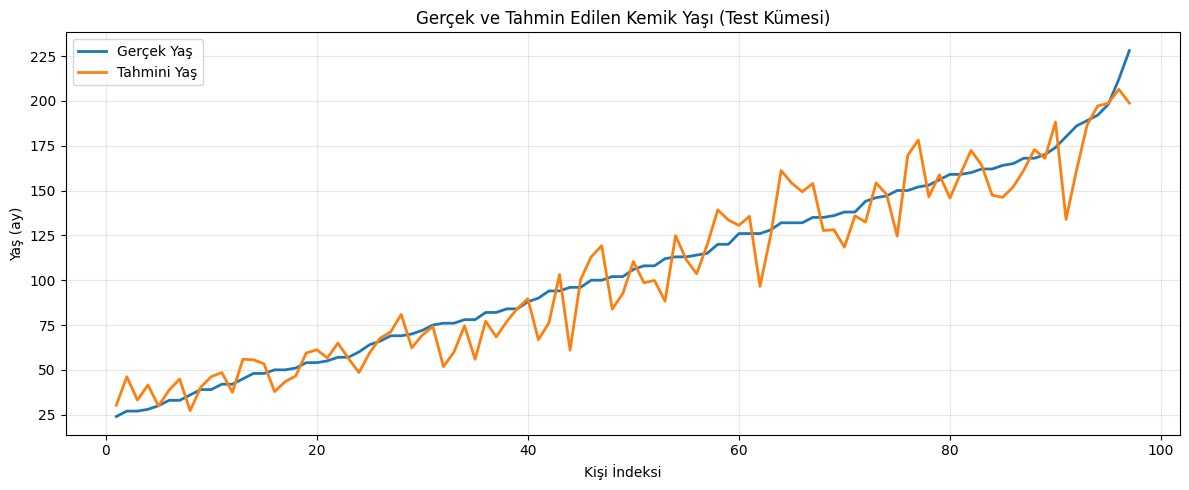


📊 ÖZET
Test MAE : 10.73 ay
Test RMSE: 13.86
Test R²  : 0.92



In [3]:
# =========================================================
# 5. INFERENCE & SUNUM (FINAL MODEL - SADECE TAHMİN)
# =========================================================

import os
import cv2
import math
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input


from google.colab import drive
drive.mount('/content/drive')

print("🖥️ TEST / SUNUM MODU BAŞLATILDI")

# ------------------ AYARLAR ------------------
IMG_SIZE = 320
BATCH_SIZE = 8
MAX_AGE = 228
PER_PAGE = 4

# ------------------ SABİT DRIVE YOLLARI ------------------
BASE_PROJECT = "/content/drive/My Drive/BoneAgeProject"

MODEL_PATH = os.path.join(
    BASE_PROJECT,
    "models",
    "EfficientNetB0-tekCNN.keras"
)

DATASET_BASE = os.path.join(BASE_PROJECT, "DATASET")

ART_DIR = os.path.join(DATASET_BASE, "Articular_Surface_Test")
EPI_DIR = os.path.join(DATASET_BASE, "Epiphysis_Test")
TEST_CSV = os.path.join(DATASET_BASE, "test.csv")

# ------------------ KONTROLLER ------------------
if not os.path.exists(MODEL_PATH):
    raise RuntimeError(f"Model bulunamadı: {MODEL_PATH}")

if not os.path.exists(TEST_CSV):
    raise RuntimeError("test.csv bulunamadı!")

print("🧠 Model yolu :", MODEL_PATH)
print("📂 Dataset yolu:", DATASET_BASE)

# ------------------ YARDIMCI (MODELLE UYUMLU) ------------------
def load_test_csv(csv_path, art_dir, epi_dir):
    df = pd.read_csv(csv_path)

    art_paths, epi_paths, males, y_true = [], [], [], []

    for row in df.itertuples():
        pid = str(row.id)

        art = os.path.join(art_dir, pid + ".png")
        epi = os.path.join(epi_dir, pid + ".png")

        if not (os.path.exists(art) and os.path.exists(epi)):
            continue

        art_paths.append(art)
        epi_paths.append(epi)
        males.append(1.0 if row.male else 0.0)
        y_true.append(np.float32(row.boneage) / MAX_AGE)

    return art_paths, epi_paths, males, y_true

# ------------------ VERİ YÜKLE ------------------

def parse_sample(art_path, epi_path, male, y):
    art = tf.io.read_file(art_path)
    art = tf.image.decode_png(art, channels=1)
    art = tf.image.resize(art, (IMG_SIZE, IMG_SIZE))

    epi = tf.io.read_file(epi_path)
    epi = tf.image.decode_png(epi, channels=1)
    epi = tf.image.resize(epi, (IMG_SIZE, IMG_SIZE))

    const = tf.zeros_like(art)

    img = tf.concat([art, epi, const], axis=-1)
    img = preprocess_input(img)

    return {
        "img_input": img,
        "male_input": tf.expand_dims(male, -1)
    }, y


art_p, epi_p, male_p, y_true = load_test_csv(
    TEST_CSV, ART_DIR, EPI_DIR
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (art_p, epi_p, tf.cast(male_p, tf.float32), tf.cast(y_true, tf.float32))
)

test_ds = (
    test_ds
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"✅ Toplam test örneği: {len(y_true)}")

# ------------------ MODEL YÜKLE ------------------
model = load_model(MODEL_PATH, compile=False)
print("🏆 Final model yüklendi")

# ------------------ TAHMİN ------------------
preds = model.predict(test_ds, verbose=0).flatten()

pred_ages = preds * MAX_AGE
y_true = np.array(y_true) * MAX_AGE
errors = np.abs(pred_ages - y_true)
ss_res = np.sum((y_true - pred_ages) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean((pred_ages - y_true) ** 2))

# ------------------ ÇİZGİ GRAFİĞİ ------------------
plt.figure(figsize=(12, 5))
x = np.arange(1, len(y_true) + 1)

plt.plot(x, y_true, label="Gerçek Yaş", linewidth=2)
plt.plot(x, pred_ages, label="Tahmini Yaş", linewidth=2)

plt.xlabel("Kişi İndeksi")
plt.ylabel("Yaş (ay)")
plt.title("Gerçek ve Tahmin Edilen Kemik Yaşı (Test Kümesi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ METİNSEL ÖZET ------------------
print("\n📊 ÖZET")
print(f"Test MAE : {errors.mean():.2f} ay")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²  : {r2:.2f}\n")